In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [38]:
df = pd.read_csv("https://raw.githubusercontent.com/azminewasi/Kaggle-Datasets/main/CR7%20-Club%20Goals/data.csv", encoding="latin-1")
df.head()

,Unnamed: 0,Goal_no,Season,Competition,Matchday,Venue,Team,Opponent,Result,Position,Minute,At_score,Type_of_goal
0,0,1,2/3,Liga Portugal,6,H,Sporting CP,Moreirense FC,3:0,LW,34,2:0,Solo run
1,1,2,2/3,Liga Portugal,6,H,Sporting CP,Moreirense FC,3:0,NaN,90+5,3:0,Header
2,2,3,2/3,Liga Portugal,8,A,Sporting CP,Boavista FC,1:2,NaN,88,1:2,Right-footed shot
3,3,4,2/3,TaÃÂ§a de Portugal Placard,Fourth Round,H,Sporting CP,CD Estarreja,4:1,NaN,67,3:0,Left-footed shot
4,4,5,2/3,TaÃÂ§a de Portugal Placard,Fifth Round,H,Sporting CP,FC Oliveira do Hospital,8:1,NaN,13,3:0,NaN


In [39]:
df = df.dropna(subset=["Type_of_goal"])
df["Minute"] = pd.to_numeric(df["Minute"], errors="coerce")
df = df.dropna(subset=["Minute"])
le = LabelEncoder()
df["Venue_enc"] = le.fit_transform(df["Venue"])
df["Team_enc"] = le.fit_transform(df["Team"])
df["Competition_enc"] = le.fit_transform(df["Competition"])
df["Venue_enc"] = le.fit_transform(df["Venue"])

In [40]:
X = df[["Minute", "Venue_enc", "Team_enc", "Competition_enc"]]
y = df["Type_of_goal"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [52]:
print("Accuracy:", round(accuracy_score(y_test, model.predict(X_test)) * 100, 1), "%")

Accuracy: 22.9 %


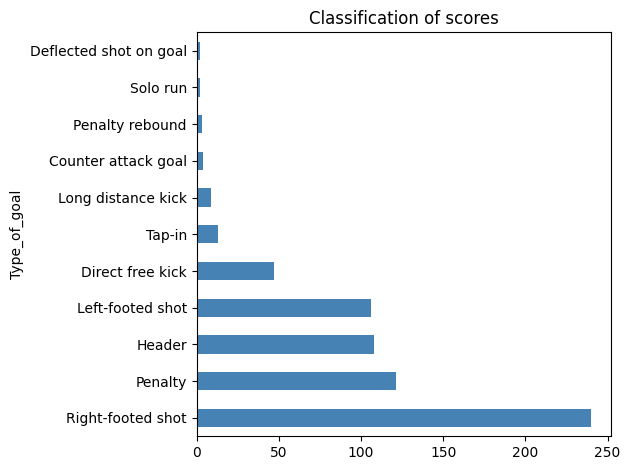

In [53]:
df["Type_of_goal"].value_counts().plot(kind="barh", title="Classification of scores", color="steelblue")
plt.tight_layout()
plt.show()